# 12 시계열 예측을 위한 딥러닝 소개

지금까지는 월별, 분기별, 연간 등 큰 단위와 데이터가 작은 경우.  
일별 계절성이 있거나 데이터 집합이 큰 경우 지금까지의 방식은 느리고 성능 저하.  

--- 

# 12.1 언제쓰나?

대규모 데이터 집합이 있을 때.  
시계열의 경우, 데이터 요소가 10000개 이상이면 큰 것으로 간주. 크면 SARIMAX 모델에 약간의 변화가 있더라도 피팅하는 데 시간이 오래 걸리며, 일반적으로 모델 선택 단계에서 많은 모델을 피팅해야 하기 때문에 모델 선택에 적합하지 않음.  

데이터에 **여러 가지 계절적 시간**이 있는 경우 SARIMAX 모델을 사용할 수 없음.
- 시간별 기온을 예측한다고 했을 때, 밤에는 기온이 낮보다는 낮고 낮에는 기온이 높으므로 일별 계절성이 았다 할 수 있지만, 겨울에는 기온이 낮고 여름에는 기온이 높아 연간 계절성도 존재. 이런 경우 딥러닝을 사용해 두 계절의 정보를 모두 활용해 예측할 수 있음. 

딥러닝은 통계적 모델을 피팅하는 데 너무 많은 시간이 걸리거나, 백색소음에 가깝지 않고 상관관계가 있는 잔차가 있을 때 사용. 이는 모델에서 고려할 수 없는 다른 계절적 기간이 존재하거나 단순히 특징과 대상 간에 비선형 관계가 있기 때문일 수도 있음. 이런 경우 딥러닝 모델을 사용하여 비선형 관계를 포착할 수도 있고, 훈련 속도가 빠르다는 추가적인 이점도 있음. 

# 12.2 다양한 유형의 딥러닝 모델

단일 단계 모델
- 출력: 한 변수의 미래의 한 단계에 대한 예측을 나타내는 단일값. 
    - 1 * 1

다중 단계 모델
- 하나의 대상에 대한 값을 미래의 여러 시간 단계에 대한 값으로 출력
- ex) 시간별 데이터가 주어지면 다음 24시간을 예측하고 싶을 수 있는데, 이 경우 미래의 24개 시간 단계를 예측하므로 다중 단계 모델을 사용. 
    -  24 * 1

다중 출력 모델
- 둘 이상의 대상에 대한 예측 생성
- ex) 온도아 습도를 모두 예측하고 싶을 때
    - 24 * 2

각 모델은 서로 다른 아키텍쳐를 가질 수 있음.
- ex) CNN을 단일 단계, 또는 다중 단계, 또는 다중 출력 모델로 가능

In [2]:
import pandas as pd

데이터: UCI ML Repo

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/metro_interstate_traffic_volume_preprocessed.csv')

df

,date_time,temp,rain_1h,snow_1h,clouds_all,traffic_volume
0,2016-09-29 17:00:00,291.75,0.0,0,0,5551.0
1,2016-09-29 18:00:00,290.36,0.0,0,0,4132.0
2,2016-09-29 19:00:00,287.86,0.0,0,0,3435.0
3,2016-09-29 20:00:00,285.91,0.0,0,0,2765.0
4,2016-09-29 21:00:00,284.31,0.0,0,0,2443.0
...,...,...,...,...,...,...
17546,2018-09-30 19:00:00,283.45,0.0,0,75,3543.0
17547,2018-09-30 20:00:00,282.76,0.0,0,90,2781.0
17548,2018-09-30 21:00:00,282.73,0.0,0,90,2159.0
17549,2018-09-30 22:00:00,282.09,0.0,0,90,1450.0


date_time: 날짜 및 시간  
temp: 시간 단계로 기록된 평균 온도, Kelvin 기온  
rain_Th: 한 시간 동안 내린 비의 양, mm기준  
snow_Th: 한 시간 동안 내린 눈의 양, mm  
clouds_all: 한 시간 동안 구름이 덮인 비율  
traffic_volume: 한 시간 동안 I-94에서 서쪽으로 보고된 교통량

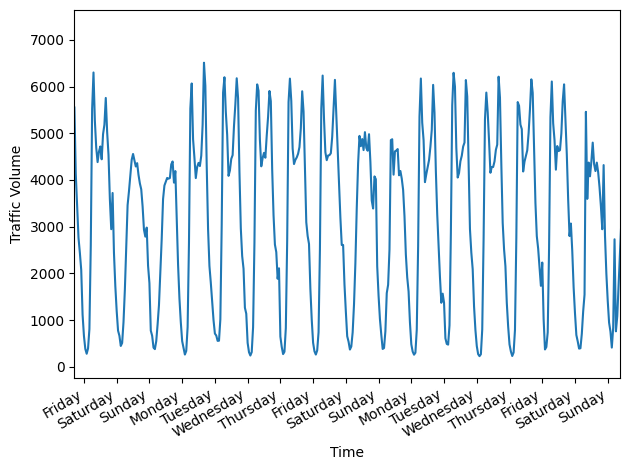

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(df['traffic_volume'])
ax.set_xlabel('Time')
ax.set_ylabel('Traffic Volume')

plt.xticks(np.arange(7, 400, 24), ['Friday', 'Saturday', 'Sunday', 'Monday',
                                   'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
                                   'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 
                                   'Friday', 'Saturday', 'Sunday'])

plt.xlim(0, 400)

fig.autofmt_xdate()
plt.tight_layout()

하루의 끝과 시작에서 교통량이 더 적음 --> 일별 계절성  
주말: 교통량이 더 적음